# Skill Workflow Orchestration



This pattern packages tool calls plus decision logic into a reusable workflow. In practice, this is where many production agent systems become reliable.



## Stack

- Framework: LangGraph workflow graph

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: repeatable business outcomes



## When to use it

- You want consistent business outcomes

- The same sequence is reused across many requests

## Architecture



```mermaid

graph TD

    U[Destination Request] --> F[Flight Tool]

    U --> H[Hotel Tool]

    U --> W[Weather Tool]

    F --> S[Skill Orchestrator]

    H --> S

    W --> S

    S --> L[Local Ollama Summary]

```

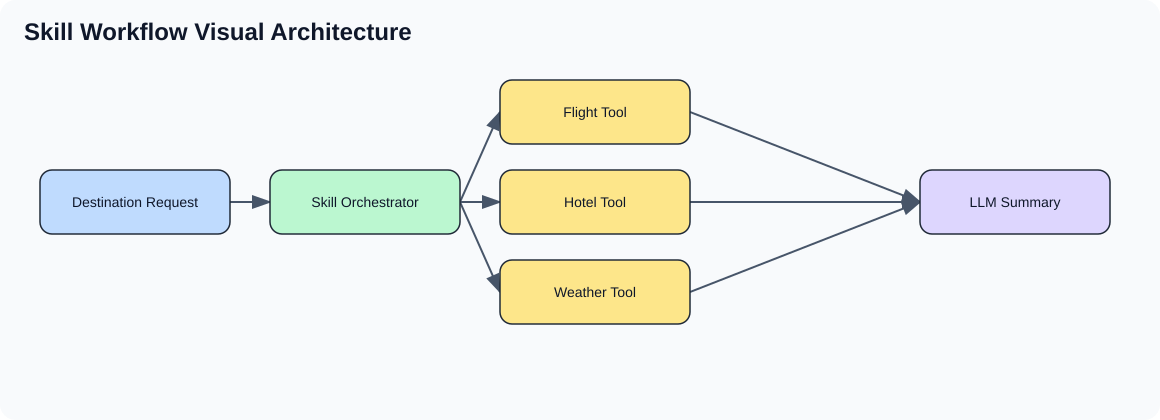

In [3]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("request", "Destination Request", 40, 170, "#bfdbfe"),

    ("flow", "Skill Orchestrator", 270, 170, "#bbf7d0"),

    ("flights", "Flight Tool", 500, 80, "#fde68a"),

    ("hotels", "Hotel Tool", 500, 170, "#fde68a"),

    ("weather", "Weather Tool", 500, 260, "#fde68a"),

    ("summary", "LLM Summary", 920, 170, "#ddd6fe"),

]

edges = [

    ("request", "flow"),

    ("flow", "flights"),

    ("flow", "hotels"),

    ("flow", "weather"),

    ("flights", "summary"),

    ("hotels", "summary"),

    ("weather", "summary"),

]



render_svg_flow("Skill Workflow Visual Architecture", nodes, edges, width=1160, height=420)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Skill Workflow State Graph

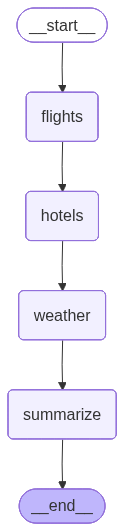

{"level": "INFO", "event_type": "tool_called", "tool_name": "search_flights", "destination": "Singapore"}
{"level": "INFO", "event_type": "tool_called", "tool_name": "search_hotels", "destination": "Singapore"}
{"level": "INFO", "event_type": "tool_called", "tool_name": "check_weather", "destination": "Singapore"}
{"level": "INFO", "event_type": "travel_summary_start", "destination": "Singapore"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Return EXACTLY 4 bullet points.\nEach bullet must start with '- '.\nEach bullet mu"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}


{'destination': 'Singapore',
 'flights': 'Flights found for Singapore: morning and evening options available.',
 'hotels': 'Hotels found for Singapore: central business district and waterfront.',
 'weather': 'Weather for Singapore: mild and clear.',
 'summary': 'Here are the 4 bullet points as requested:\n\n- Flights found for Singapore with morning and evening options available.\n- Hotels found in central business district and waterfront areas of Singapore.\n- Weather forecast for Singapore is mild and clear conditions expected.\n- Flight and hotel options have been gathered and verified successfully.',
 'history': ['Flight options gathered',
  'Hotel options gathered',
  'Weather checked',
  'Trip recommendation drafted']}

In [ ]:
from langchain_core.tools import tool

from langgraph.graph import END, START, StateGraph



from agent_pattern_states import TravelState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    get_local_llm,

    invoke_with_retry,

    log_event,

    render_state_graph,

)





@tool

def search_flights(destination: str) -> str:

    """Find flight options for a destination."""

    log_event("info", "tool_called", tool_name="search_flights", destination=destination)

    return f"Flights found for {destination}: morning and evening options available."





@tool

def search_hotels(destination: str) -> str:

    """Find hotel options for a destination."""

    log_event("info", "tool_called", tool_name="search_hotels", destination=destination)

    return f"Hotels found for {destination}: central business district and waterfront."





@tool

def check_weather(destination: str) -> str:

    """Get weather conditions for a destination."""

    log_event("info", "tool_called", tool_name="check_weather", destination=destination)

    return f"Weather for {destination}: mild and clear."





llm = get_local_llm()





def flights_node(state: TravelState) -> TravelState:

    return {

        "flights": search_flights.invoke({"destination": state["destination"]}),

        "history": append_history(state.get("history"), "Flight options gathered"),

    }





def hotels_node(state: TravelState) -> TravelState:

    return {

        "hotels": search_hotels.invoke({"destination": state["destination"]}),

        "history": append_history(state["history"], "Hotel options gathered"),

    }





def weather_node(state: TravelState) -> TravelState:

    return {

        "weather": check_weather.invoke({"destination": state["destination"]}),

        "history": append_history(state["history"], "Weather checked"),

    }





def summarize_node(state: TravelState) -> TravelState:

    log_event("info", "travel_summary_start", destination=state["destination"])

    prompt = (

        "Return EXACTLY 4 bullet points.\n"

        "Each bullet must start with '- '.\n"

        "Each bullet must be <= 14 words.\n"

        f"Destination: {state['destination']}\n"

        f"Flights: {state['flights']}\n"

        f"Hotels: {state['hotels']}\n"

        f"Weather: {state['weather']}\n"

        f"History: {state['history']}"

    )

    return {

        "summary": invoke_with_retry(llm, prompt),

        "history": append_history(state["history"], "Trip recommendation drafted"),

    }





builder = StateGraph(TravelState)

builder.add_node("flights", flights_node)

builder.add_node("hotels", hotels_node)

builder.add_node("weather", weather_node)

builder.add_node("summarize", summarize_node)

builder.add_edge(START, "flights")

builder.add_edge("flights", "hotels")

builder.add_edge("hotels", "weather")

builder.add_edge("weather", "summarize")

builder.add_edge("summarize", END)



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Skill Workflow State Graph")



result = graph.invoke(

    {

        "destination": "Singapore",

        "flights": "",

        "hotels": "",

        "weather": "",

        "summary": "",

        "history": [],

    },

    config={"configurable": {"thread_id": "travel-skill-demo"}},

)



result

## Design insight



This pattern is usually the best boundary for reuse. Tools are infrastructure. The skill graph is the reusable business capability.